# Chọn dữ liệu là text với tám câu mẫu.

# Bài 1

## 1.1. Biến dữ liệu thành ma trận

In [3]:
import numpy as np
 # ===== Neu chon TEXT (bag -of - words ) =====
cau = ["na na na na anh Do Mixi", 
       "Sai Gon nam o mien Nam nuoc Viet Nam",
       "Messi ghi hattrick o tran dau giua Argentina va Jordan",
       "Mbappe la ninja rua",
       "Con Dao thuoc dia phan cua thanh pho Ho Chi Minh sau khi xac nhap",
       "bai tap nay khong duoc sai thu vien machine learning cap cao cua Python",
       "doi tuyen Nhat Ban la doi manh nhat chau A",
       "vai tuan nua la phai di hoc lai roi"] # >= 8 cau
vocab = sorted ({ w for s in cau for w in s.lower().split () })
def to_vector(s):
  v = np.zeros(len(vocab))
  for w in s .lower().split ():
    v[ vocab.index(w)] += 1
  return v
X = np.array ([ to_vector ( s ) for s in cau ]) # ( so_cau , so_tu )
print ( X.shape )

(8, 66)


**Vậy, có 8 hàng và 66 cột**.
- 8  hàng là đại diện cho 8 câu theo thứ tự mảng từ 0 -> 7
- 66 cột là đại diện cho từng từ vựng duy nhất trong tập vocab, được chuyển thành in thường

Giá trị tại ô X[i, j] (hàng i, cột j) chính là số lần xuất hiện của từ thứ j nằm trong câu thứ i.


## 1.2. Phép toán cơ bản.
- Tính vector trung bình theo cột, trừ trung bình (broadcasting), in shape trước/sau để minh họa quy tắc broadcasting.

In [4]:
# 1. vector trung bình theo cột (axis=0)
X_mean = X.mean(axis=0)

# 2. phép trừ trung bình áp dụng Broadcasting
X_Boardcast = X - X_mean

# 3. kích thước trước và sau để minh họa Broadcasting
print("Kích thước ma trận gốc:      ", X.shape)
print("Kích thước vector trung bình:  ", X_mean.shape)
print("Kích thước ma trận sau khi trừ:", X_Boardcast.shape)


Kích thước ma trận gốc:       (8, 66)
Kích thước vector trung bình:   (66,)
Kích thước ma trận sau khi trừ: (8, 66)


## 1.3. Cosine similarity
- Hoàn thiện hàm cosine_similarity(X, Y=None) cho batch (chuẩn
hóa theo hàng, keepdims=True), trả về ma trận tương đồng.

In [9]:
def cosine_similarity (X, Y = None ) :
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm (X , axis =1 , keepdims = True )
    Yn = Y / np.linalg.norm (Y , axis =1 , keepdims = True )
    return Xn @ Yn.T

In [10]:
# 1. tính ma trận tương đồng cosine giữa 8 câu với chính chúng
S = cosine_similarity(X)

# 2. so 8 câu với 8 câu nên ra ma trận vuông
print("Kích thước ma trận tương đồng:", S.shape)

# 3. in ma trận, làm tròn 2 chữ số cho dễ nhìn
print("\nMa trận cosine similarity (làm tròn 2 số):")
print(np.round(S, 2))

Kích thước ma trận tương đồng: (8, 8)

Ma trận cosine similarity (làm tròn 2 số):
[[1.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   1.   0.08 0.   0.   0.07 0.   0.  ]
 [0.   0.08 1.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   1.   0.   0.   0.13 0.17]
 [0.   0.   0.   0.   1.   0.07 0.   0.  ]
 [0.   0.07 0.   0.   0.07 1.   0.   0.  ]
 [0.   0.   0.   0.13 0.   0.   1.   0.09]
 [0.   0.   0.   0.17 0.   0.   0.09 1.  ]]


**Vậy, ma trận tương đồng có kích thước 8x8 và đối xứng qua đường chéo chính**.
- Đường chéo chính toàn bằng 1, vì mỗi câu so với chính nó thì giống nhau.
- Ô S[i, j] = S[j, i] cho biết câu i và câu j giống nhau như nào: bằng 1 là cùng hướng, bằng 0 là ko dùng chung từ nào.
- Vì vector bag-of-words không có giá trị âm nên cosine ở đây luôn nằm trong khoảng [0, 1].

## 1.4. Truy vấn
- Viết hàm search(query, top_k=3) trả về top_k mục giống truy vấn nhất
kèm điểm cosine.

In [ ]:
# 1. hàm search: đưa câu truy vấn về vector rồi tìm top_k câu giống nhất
def search(query, top_k=3):
    # đếm số lần xuất hiện của từ
    q = np.zeros(len(vocab))
    for w in query.lower().split():
        if w in vocab:
            q[vocab.index(w)] += 1
    # tính cosine giữa câu truy vấn và cả 8 câu trong X
    sims = cosine_similarity(q.reshape(1, -1), X)[0]
    # lấy chỉ số các câu điểm cao nhất, sắp xếp giảm dần
    top_idx = np.argsort(sims)[::-1][:top_k]
    # trả về danh sách (câu, điểm cosine)
    return [(cau[i], sims[i]) for i in top_idx]
 
query = "Nhat Ban la doi manh"
print("Câu truy vấn:", query, "\n")

# 2. in ra top 3 câu giống nhất kèm điểm cosine
for thu_hang, (s, diem) in enumerate(search(query, top_k=3), start=1):
    print(f"{thu_hang}. (cosine = {diem:.3f})  {s}")

Câu truy vấn: Nhat Ban la doi manh 

1. (cosine = 0.837)  doi tuyen Nhat Ban la doi manh nhat chau A
2. (cosine = 0.224)  Mbappe la ninja rua
3. (cosine = 0.149)  vai tuan nua la phai di hoc lai roi


**Hàm `search` trả về đúng top 3 câu giống câu truy vấn nhất, kèm điểm cosine giảm dần**.
- Câu truy vấn "Nhat Ban la doi manh" được đưa về cùng không gian 66 chiều như X rồi mới đem so.
- Câu đứng đầu đúng là câu nói về đội tuyển Nhật Bản (cosine ≈ 0.84), đây là câu đúng nhất trong 8 câu mẫu.

# 1.5. Nhận xét
- Cặp nào giống nhau nhất, cặp nào khác biệt nhất? Kết quả có khớptrực giác không?

In [ ]:
import matplotlib.pyplot as plt

# 1. tìm cặp câu giống nhất và khác nhất nửa trên ma trận (i < j) 
n = len(cau)
cap_giong_nhat = (-1, None)
cap_khac_nhat = (2, None)
for i in range(n):
    for j in range(i + 1, n):
        diem = S[i, j]
        if diem > cap_giong_nhat[0]:
            cap_giong_nhat = (diem, (i, j))
        if diem < cap_khac_nhat[0]:
            cap_khac_nhat = (diem, (i, j))

# 2. in cặp giống nhau nhất và cặp khác biệt nhất kèm nội dung câu
i, j = cap_giong_nhat[1]
print(f"Cặp giống nhau nhất: câu {i} & câu {j} (cosine = {cap_giong_nhat[0]:.3f})")
print(f"   [{i}] {cau[i]}")
print(f"   [{j}] {cau[j]}")
i, j = cap_khac_nhat[1]
print(f"\nCặp khác biệt nhất:  câu {i} & câu {j} (cosine = {cap_khac_nhat[0]:.3f})")
print(f"   [{i}] {cau[i]}")
print(f"   [{j}] {cau[j]}")

# 3. vẽ heatmap ma trận tương đồng cho dễ nhìn tổng quan
plt.figure(figsize=(6, 5))
plt.imshow(S, cmap="viridis")
plt.colorbar(label="cosine similarity")
plt.title("Ma tran tuong dong giua 8 cau")
plt.xlabel("Cau thu j")
plt.ylabel("Cau thu i")
plt.xticks(range(n))
plt.yticks(range(n))
plt.show()

**Kết quả không khớp với trực giác**.

- **Cặp giống nhau nhất** là câu 3 ("Mbappe la ninja rua") và câu 7 ("vai tuan nua la phai di hoc lai roi") với cosine ≈ 0.17. Nhưng hai câu này chẳng liên quan gì về nội dung, chúng chỉ tình cờ dùng chung đúng một từ "la".
- **Cặp khác biệt nhất** có cosine = 0, tức là không dùng chung từ nào. Trong ma trận có rất nhiều ô bằng 0 như vậy.
- Đáng lẽ 3 câu về bóng đá (câu 2 Messi, câu 3 Mbappe, câu 6 đội tuyển Nhật Bản) phải gần nhau, nhưng điểm tương đồng gần như bằng 0, vì bag-of-words chỉ đếm từ trùng nhau chứ không hiểu nghĩa.

**Lý do:** mô hình coi mỗi câu chỉ là một tập hợp từ, nên các hư từ như "la", "o", "cua" lại chi phối điểm số. Thêm do hạ hết về chữ thường (`.lower()`), từ "Sài" (trong "Sài Gòn") bị trùng với "sai" (trong "không được sai"), khiến câu 1 và câu 5 tự nhiên giống nhau một chút dù nội dung khác hẳn.



# Bài 2

## 2.2. Giảm chiều bằng SVD. 
- Dùng np.linalg.svd đưa mỗi câu về 2 chiều (LSA thu
nhỏ).

In [22]:
Xc = X - X.mean( axis =0) # center du lieu
U , S , Vt = np.linalg.svd ( Xc , full_matrices = False )
coords = U [: , :2] * S [:2]

# in kích thước toạ độ mới 
print("Kích thước toạ độ 2D:", coords.shape)
data = (S**2).cumsum() / (S**2).sum()
print(f"giữ lại được {data[1]*100:.1f}% thông tin")

Kích thước toạ độ 2D: (8, 2)
giữ lại được 39.1% thông tin


**Vậy mỗi câu giờ chỉ còn là 1 điểm 2 chiều (`coords` có shape 8*2) so với 66 chiều ban đầu**.
- Vì đưa từ 66 chiều xuống 2 chiều nên chỉ giữ khoảng **39%** thông tin, phần còn lại bị mất rồi

## 2.3 Trực quan hóa.
- Vẽ scatter các câu trên mặt phẳng 2D, gắn nhãn từng câu.

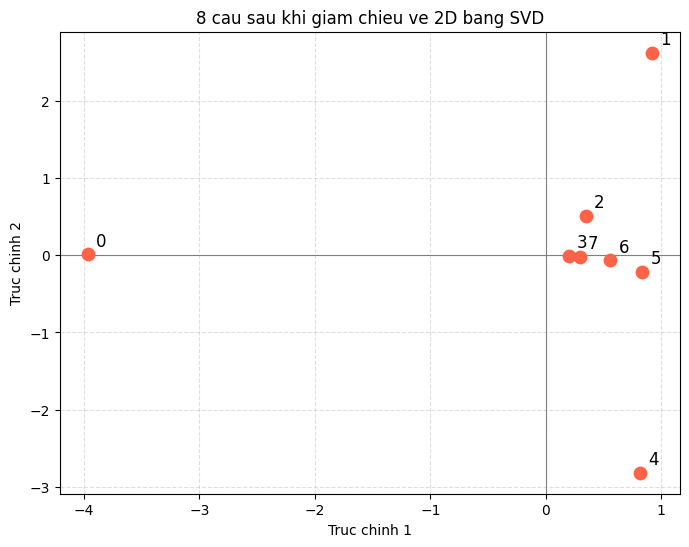

câu 0: (-3.97, +0.01)  na na na na anh Do Mixi
câu 1: (+0.92, +2.62)  Sai Gon nam o mien Nam nuoc Viet Nam
câu 2: (+0.35, +0.51)  Messi ghi hattrick o tran dau giua Argentina va Jordan
câu 3: (+0.20, -0.01)  Mbappe la ninja rua
câu 4: (+0.82, -2.82)  Con Dao thuoc dia phan cua thanh pho Ho Chi Minh sau khi xac nhap
câu 5: (+0.84, -0.22)  bai tap nay khong duoc sai thu vien machine learning cap cao cua Python
câu 6: (+0.56, -0.07)  doi tuyen Nhat Ban la doi manh nhat chau A
câu 7: (+0.29, -0.02)  vai tuan nua la phai di hoc lai roi


In [20]:
import matplotlib.pyplot as plt

# 1. vẽ mỗi câu thành 1 điểm trên mặt phẳng 2D
plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c="tomato", s=80, zorder=3)

# 2. gắn nhãn số thứ tự câu cạnh mỗi điểm 
for i, (x, y) in enumerate(coords):
    plt.annotate(str(i), (x, y), textcoords="offset points", xytext=(6, 6), fontsize=12)

# 3. kẻ 2 trục gốc 0 
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("8 cau sau khi giam chieu ve 2D bang SVD")
plt.xlabel("Truc chinh 1")
plt.ylabel("Truc chinh 2")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

# 4. in kèm bảng toạ độ 
for i, (x, y) in enumerate(coords):
    print(f"câu {i}: ({x:+.2f}, {y:+.2f})  {cau[i]}")

## 2.4 Nhận xét
- Các câu cùng chủ đề có nằm gần nhau không? Liên hệ với eigen/PCA
và “trục chính” của dữ liệu.

**Các câu cùng chủ đề ở đây chưa thực sự nằm gần nhau, vì SVD vẫn chạy trên ma trận đếm từ nên vẫn dính điểm yếu của Bài 1**.

- Câu 0 ("na na na na anh Do Mixi") bị văng hẳn sang một góc (toạ độ x ≈ -4), tách biệt với 7 câu còn lại. Do câu này lặp từ "na" tới 4 lần nên vector bị lệch rất xa trung bình, khiến **trục chính 1 gần như chỉ để phân biệt mình nó** với phần còn lại.
- Trên trục 2, hai câu về địa điểm là câu 1 (Sài Gòn) và câu 4 (Côn Đảo / TP.HCM) lại nằm ở hai cực ngược nhau dù cùng chủ đề, còn 3 câu bóng đá (2, 3, 6) thì chụm gần gốc toạ độ nhưng không tách thành một cụm rõ ràng.
- Nói cách khác, khoảng cách trên hình vẫn hiển thị theo kiểu có dùng chung từ hay không, chứ chưa phải có cùng nghĩa hay không.

**Liên hệ eigen/PCA:** Khi chúng ta thực hiện bước **Xc = X - X.mean(axis=0)** và áp dụng SVD lên ma trận này thì đây chính là thuật toán PCA. Các hàng của ma trận $Vt$ chính là các vector riêng. Các vector này tạo nên một hệ trục tọa độ mới. Hai trục trên đồ thị (Trục chính 1 và 2) chính là hai hướng mà dữ liệu của chúng ta phân bổ nhiều nhất. Việc ta lấy U[:, :2] * S[:2] bản chất là đang chiếu 8 câu mẫu ban đầu từ một không gian 66 chiều xuống mặt phẳng 2D này sao cho giữ lại được nhiều thông tin phân biệt nhất. Nhờ đó ta mới được các câu văn bằng mắt thường.

 2 chiều đầu chỉ giữ lại **cỡ 39%** thông tin (chạy mục 2.2), bỏ đi hơn 60% thông tin, nên hình 2D mới chỉ là một bản xấp xỉ. Muốn các câu cùng chủ đề gom cụm rõ hơn thì dùng embedding thay cho đếm từ để khắc phục nhược điểm của phương pháp Bag of words.